# Unicycle Circular Path Following (Lyapunov Design)

We implement a non-linear path-following controller. For a circle of radius $R$ centered at the origin, we define the errors:
- Cross-track error (distance to the circle): $e = \sqrt{x^2 + y^2} - R$
- Heading error: $\tilde{\theta} = \theta - \theta_p$, where $\theta_p$ is the tangent angle $\psi + \frac{\pi}{2}$ (with $\psi = \text{atan2}(y, x)$).

This defines the kinematics:
$\dot{e} = -v \sin(\tilde{\theta})$

$\dot{\tilde{\theta}} = \omega - \frac{v \cos(\tilde{\theta})}{R + e}$

We choose a Lyapunov function:
$V = \frac{1}{2}e^2 + \frac{1}{k_y}(1 - \cos \tilde{\theta})$

Let's trace the symbolic derivative and ensure it is negative semi-definite.

In [8]:
import sys
from pathlib import Path

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from IPython.display import display, Math
import sympy as sp

from src.symbolic.lyapunov import derive_circular_path_following

sym_res = derive_circular_path_following()

display(Math(r'V = ' + sp.latex(sym_res['V'])))
display(Math(r'\dot{e} = ' + sp.latex(sym_res['e_dot'])))
display(Math(r'\dot{\tilde{\theta}} = ' + sp.latex(sym_res['t_tilde_dot'])))
display(Math(r'\text{Proposed } \omega = ' + sp.latex(sym_res['omega_law'])))
display(Math(r'\implies \dot{V} = ' + sp.latex(sym_res['V_dot_sub']) + r' \le 0'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Since $\dot{V} = -\frac{k_\theta}{k_y} \sin^2(\tilde{\theta}) \le 0$, the system is stable. By LaSalle's invariance principle, the system converges to the largest invariant set where $\dot{V} = 0$, which is $e=0, \tilde{\theta}=0$ (perfect tracking).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.simulation.video_sim import VideoSim
from src.utils.config import load_config

config_path = str(ROOT / "config/unicycle_lyapunov.yaml")
cfg = load_config(config_path)

In [10]:
class UnicycleLyapunovSim(VideoSim):
    def __init__(self, config):
        super().__init__(config)
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model needs a free root joint.")

        self.start_z = 0.5
        qw = np.cos(3 * np.pi / 8)
        qz = np.sin(3 * np.pi / 8)
        self.data.qpos[:7] = np.array([3.0, 0.0, self.start_z, qw, 0.0, 0.0, qz])
        self.data.qvel[:6] = 0.0

        control_cfg = self.cfg.get('control', {})
        self.v      = float(control_cfg.get('v',      1.0))
        self.R      = float(control_cfg.get('R',      1.5))
        self.ky     = float(control_cfg.get('ky',     1.0))
        self.ktheta = float(control_cfg.get('ktheta', 2.0))

        # ── own kinematic state (immune to MuJoCo gravity / contact) ──────
        self._x     = 3.0
        self._y     = 0.0
        # initial yaw from pure-yaw quaternion (qx = qy = 0)
        self._theta = np.arctan2(2.0 * qw * qz, 1.0 - 2.0 * qz**2)

        # virtual vehicle reference angle (display only)
        self._psi_ref = 0.0

        # ── camera settings (read from config or use sensible defaults) ──
        cam_cfg = self.cfg.get('camera', {})
        self._cam_lookat   = np.array(cam_cfg.get('lookat',    [0.0, 0.0, 0.0]))
        self._cam_distance = float(cam_cfg.get('distance',  20.0))
        self._cam_elevation= float(cam_cfg.get('elevation', -70.0))
        self._cam_azimuth  = float(cam_cfg.get('azimuth',   90.0))

    def _capture_frame(self):
        # ── write into the renderer's own internal MjvCamera ─────────────
        # (this is the object actually used when no camera= is passed)
        self._camera.lookat[:] = self._cam_lookat
        self._camera.distance  = self._cam_distance
        self._camera.elevation = self._cam_elevation
        self._camera.azimuth   = self._cam_azimuth

        self._renderer.update_scene(
            self.data,
            camera=self._camera
        )

        pixels = self._renderer.render()
        self._frames.append(pixels)

    # ─────────────────────────────────────────────────────────────────────
    def _loop_step(self, t: float, step: int):
        dt = self.model.opt.timestep          # MuJoCo timestep

        # ── 1. read OWN state, not MuJoCo's (which may be gravity-corrupted)
        x, y, theta = self._x, self._y, self._theta

        # ── 2. path errors ─────────────────────────────────────────────────
        r       = np.hypot(x, y) + 1e-9
        e       = r - self.R
        psi     = np.arctan2(y, x)
        theta_p = psi + np.pi / 2

        # heading error wrapped to [-π, π]
        t_tilde = (theta - theta_p) % (2 * np.pi)
        if t_tilde > np.pi:
            t_tilde -= 2 * np.pi

        # ── 3. Lyapunov control law ────────────────────────────────────────
        t_p_dot = (self.v * np.cos(t_tilde)) / (self.R + e)
        omega   = t_p_dot + self.ky * e * self.v - self.ktheta * np.sin(t_tilde)

        # ── 4. forward-Euler integration of the unicycle kinematics ────────
        #       non-holonomic: velocity is always in the heading direction
        x_new     = x + self.v * np.cos(theta) * dt
        y_new     = y + self.v * np.sin(theta) * dt
        theta_new = (theta + omega * dt + np.pi) % (2 * np.pi) - np.pi

        self._x, self._y, self._theta = x_new, y_new, theta_new

        # ── 5. write CLEAN state to MuJoCo (for rendering only) ───────────
        #       enforce: fixed height, zero roll, zero pitch
        self.data.qpos[0] = x_new
        self.data.qpos[1] = y_new
        self.data.qpos[2] = 0.15                    # ← fixed height (radius of unicycle)
        self.data.qpos[3] = np.cos(theta_new / 2)   # qw  ─┐ pure yaw
        self.data.qpos[4] = 0.0                     # qx  ─┤ no roll
        self.data.qpos[5] = 0.0                     # qy  ─┤ no pitch
        self.data.qpos[6] = np.sin(theta_new / 2)   # qz  ─┘

        # velocities consistent with kinematic model
        self.data.qvel[0] = self.v * np.cos(theta_new)
        self.data.qvel[1] = self.v * np.sin(theta_new)
        self.data.qvel[2] = 0.0                     # no vertical vel
        self.data.qvel[3] = 0.0                     # no roll rate
        self.data.qvel[4] = 0.0                     # no pitch rate
        self.data.qvel[5] = omega                   # yaw rate

        # ── 6. virtual vehicle (display only, moves independently) ─────────
        self._psi_ref += (self.v / self.R) * dt
        xd = self.R * np.cos(self._psi_ref)
        yd = self.R * np.sin(self._psi_ref)

        self.logger.log({
            "t": t, "x": float(x), "y": float(y),
            "xd": float(xd), "yd": float(yd),
            "e": float(e), "t_tilde": float(t_tilde), "omega": float(omega),
        })

In [11]:
sim = UnicycleLyapunovSim(config_path)
sim.run()
df = sim.to_dataframe()
df.tail()

Simulation: 100%|██████████| 3000/3000 [00:01<00:00, 2036.29step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/unicycle_lyapunov.mp4


,t,x,y,xd,yd,e,t_tilde,omega
2995,14.975,-1.444461,0.416574,-1.269376,-0.799178,0.00333,0.001666,0.665188
2996,14.980,-1.445838,0.411768,-1.266705,-0.803405,0.00333,0.001666,0.665188
2997,14.985,-1.447200,0.406957,-1.264019,-0.807623,0.00333,0.001666,0.665188
2998,14.990,-1.448545,0.402141,-1.261320,-0.811832,0.00333,0.001666,0.665188
2999,14.995,-1.449875,0.397321,-1.258607,-0.816032,0.00333,0.001666,0.665188


In [12]:
from IPython.display import Video, Image, display

video_path = Path(load_config(config_path)['video_path'])
if not video_path.is_absolute():
    video_path = ROOT / video_path

if video_path.exists():
    display(Video(str(video_path), embed=True))
else:
    frames_dir = video_path.parent / (video_path.stem + '_frames')
    if frames_dir.exists():
        pngs = sorted(frames_dir.glob('*.png'))
        if pngs:
            display(Image(str(pngs[-1])))
            print(f"MP4 not available. Showing last frame from {frames_dir}")

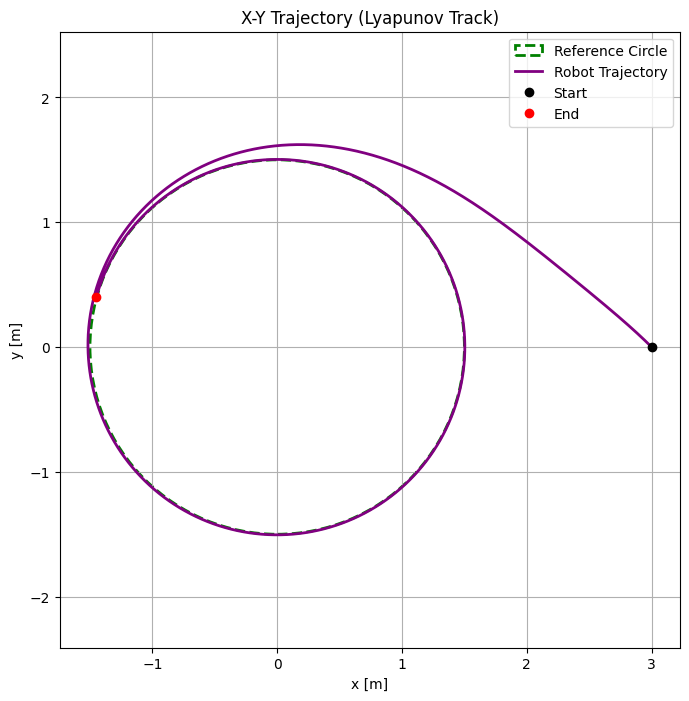

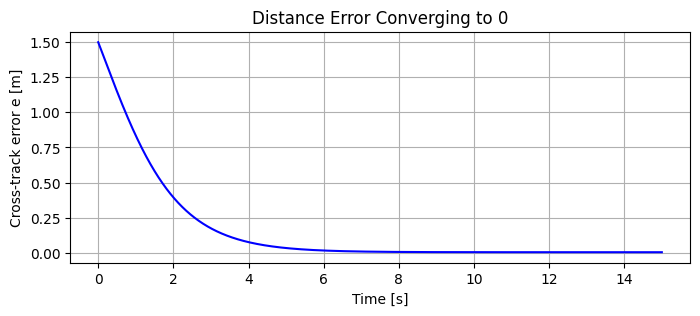

In [13]:
plt.figure(figsize=(8, 8))

# Plot the reference circle
circle = plt.Circle((0, 0), float(cfg['control']['R']), color='green', fill=False, linestyle='--', linewidth=2, label='Reference Circle')
plt.gca().add_patch(circle)

# Plot the trajectory
plt.plot(df['x'], df['y'], color='purple', linewidth=2, label='Robot Trajectory')
plt.plot(df['x'].iloc[0], df['y'].iloc[0], 'ko', label='Start')
plt.plot(df['x'].iloc[-1], df['y'].iloc[-1], 'ro', label='End')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('X-Y Trajectory (Lyapunov Track)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(df['t'], df['e'], color='blue')
plt.xlabel('Time [s]')
plt.ylabel('Cross-track error e [m]')
plt.title('Distance Error Converging to 0')
plt.grid(True)
plt.show()

In [14]:
from matplotlib import animation
from IPython.display import HTML

fig_anim = plt.figure(figsize=(8, 8))
ax_anim = fig_anim.add_subplot(1, 1, 1)
ax_anim.axis('equal')

# Using the dataframe to extract signals
x_signal = np.vstack([df['x'].values, df['y'].values])
xd_signal = np.vstack([df['xd'].values, df['yd'].values])
t_signal = df['t'].values

# Plot the complete reference path in the background
theta_circle = np.linspace(0, 2*np.pi, 100)
circle_x = float(cfg['control']['R']) * np.cos(theta_circle)
circle_y = float(cfg['control']['R']) * np.sin(theta_circle)
ax_anim.plot(circle_x, circle_y, label='Reference Path', color='r', linestyle='dashed', alpha=0.5)

ax_anim.set_xlabel('$x_1 [m]$')
ax_anim.set_ylabel('$x_2 [m]$')
ax_anim.grid(True)

# Initialize title text and legend
txt_title = ax_anim.set_title('')

# Plot elements that will be updated in the animation
line_real, = ax_anim.plot([], [], 'b-', lw=2, label='Real Trajectory')
pt_real, = ax_anim.plot([], [], 'bo', ms=10, label='Real Vehicle')
pt_virtual, = ax_anim.plot([], [], 'ro', ms=10, label='Virtual Vehicle')

ax_anim.legend(loc='lower right')

# Animation frames configuration
frames = 100
size_x = len(t_signal)

def drawframe(n):
    # Determine the index corresponding to the current frame
    t_win = int(size_x / frames * (n + 1) - 1)

    # Update the trailing line for the real vehicle
    line_real.set_data(x_signal[0, 0:t_win], x_signal[1, 0:t_win])

    # Update the current positions
    pt_real.set_data([x_signal[0, t_win]], [x_signal[1, t_win]])
    pt_virtual.set_data([xd_signal[0, t_win]], [xd_signal[1, t_win]])

    # Update the title with the current simulation time
    current_time = t_signal[t_win]
    txt_title.set_text('Time = {0:.2f} s'.format(current_time))

    return (line_real, pt_real, pt_virtual, txt_title)

# Create the animation
anim = animation.FuncAnimation(fig_anim, drawframe, frames=frames, interval=50, blit=True)

# Close the figure so it doesn't render a static image above the video
plt.close(fig_anim)

# Display the animation as an HTML5 video
HTML(anim.to_html5_video())